In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("../dataset/processed_fake_news.csv")
df.head()

,content,label,clean_text,superlative_ratio,proper_noun_ratio,first_person_ratio,third_person_ratio,exclamation_ratio,avg_sentence_length,all_caps_ratio,question_ratio
0,Trump says U.S. upholds and sticks to 'one Chi...,1,Trump say U.S. uphold and stick to ' one China...,0.000000,0.270000,0.000000,0.000000,0.000000,45.000000,0.037975,0.000000
1,LOL! Marshawn Lynch’s Mommy Comes To Her Son’s...,0,LOL ! Marshawn Lynch ’s Mommy come to her Son ...,0.000000,0.209346,0.001869,0.033645,0.016822,24.000000,0.035714,0.001056
2,Casualties in explosion at airfield near Kabul...,1,casualty in explosion at airfield near Kabul :...,0.000000,0.104167,0.000000,0.000000,0.000000,30.666667,0.036585,0.000000
3,PROFESSOR Who Called Election Of President Tru...,0,PROFESSOR who call Election of President Trump...,0.004598,0.156322,0.006897,0.016092,0.000000,41.200000,0.013333,0.000000
4,"Pennsylvania state senator, Democratic officia...",1,"Pennsylvania state senator , democratic offici...",0.000000,0.179487,0.000000,0.000000,0.000000,38.333333,0.000000,0.000000


In [3]:
vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [5]:
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train, y_train)

y_pred = model_tfidf.predict(X_test)

In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.97

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       197
           1       0.96      0.99      0.97       203

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



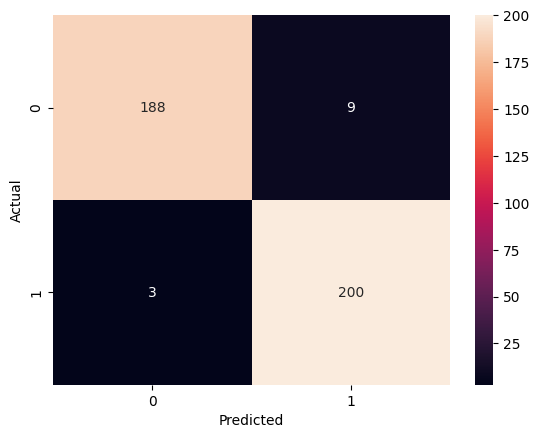

In [7]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
linguistic_features = [
    "superlative_ratio",
    "proper_noun_ratio",
    "first_person_ratio",
    "exclamation_ratio",
    "all_caps_ratio",
    "question_ratio",
    "avg_sentence_length"
]

X_linguistic = df[linguistic_features]

In [9]:
from scipy.sparse import hstack

X_combined = hstack([X_tfidf, X_linguistic])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

In [11]:
model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train, y_train)

y_pred_combined = model_combined.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred_combined))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_combined))

Accuracy: 0.97

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       197
           1       0.95      0.99      0.97       203

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [13]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       197
           1       0.96      0.99      0.98       203

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.97       400



c:\Users\hv537\OneDrive\Desktop\fake-news-detector\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [15]:
svm_combined = LinearSVC()
svm_combined.fit(X_train, y_train)

y_pred_svm_combined = svm_combined.predict(X_test)

print("SVM Combined Accuracy:", accuracy_score(y_test, y_pred_svm_combined))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm_combined))

SVM Combined Accuracy: 0.9775

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       197
           1       0.96      1.00      0.98       203

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



c:\Users\hv537\OneDrive\Desktop\fake-news-detector\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [14]:
feature_names = vectorizer.get_feature_names_out()

coefficients = model_tfidf.coef_[0]

# Top 20 words pushing toward Fake (label 0)
top_fake_indices = np.argsort(coefficients)[:20]

# Top 20 words pushing toward Real (label 1)
top_real_indices = np.argsort(coefficients)[-20:]

print("Top words for Fake News:\n")
for idx in top_fake_indices:
    print(feature_names[idx], coefficients[idx])

print("\nTop words for Real News:\n")
for idx in reversed(top_real_indices):
    print(feature_names[idx], coefficients[idx])

Top words for Fake News:

video -3.355806030652472
be -2.515428549747183
you -2.4238995082776666
this -2.325092283545662
hillary -1.9242065862094324
via -1.7388369980383644
that -1.70931853101899
obama -1.7031974763312716
just -1.6246269719480295
us -1.5174431977919756
she -1.4734956518117353
it -1.4313598040826827
they -1.4294574691190276
watch -1.318252245052035
what -1.2592741277219197
like -1.25921912525839
com -1.2528790073168687
here -1.1680979997357934
image -1.1388113714474026
her -1.1381661781250814

Top words for Real News:

say 5.749101256927539
reuters 3.9755082358942735
on 2.624575548555664
in 2.2833975680549954
washington 1.7364319482312998
government 1.543022369716385
republican 1.460548872449928
wednesday 1.4313212978542287
tuesday 1.4149563184940035
court 1.2767983983387534
minister 1.2694063505429207
its 1.1818224260740606
would 1.1086165864786657
leader 1.0981037101763025
state 1.0980230056133458
monday 1.0964061240525655
election 1.0810435504961018
by 1.079470192503

In [19]:
from sklearn.svm import SVC

svm_final = SVC(kernel="linear", probability=True)
svm_final.fit(X_combined, y)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
import joblib

joblib.dump(svm_final, "../models/fake_news_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']